# Predicting NFL Game Outcomes Using Temporal Feature Engineering and Machine Learning:
Jordin Palmeri

## Abstract

This study investigates the prediction of individual NFL game outcomes using machine learning techniques applied to engineered team statistics. We address the challenge of temporal sports prediction through a feature engineering approach that blends previous-season performance averages with expanding current-season statistics using aggressive exponential decay. Our methodology transforms raw game statistics into 71 predictive features across three categories: team performance metrics, opponent strength indicators, and differential features that directly quantify matchup advantages. We evaluate four machine learning algorithms, Logistic Regression, K-Nearest Neighbors, Random Forest, and a baseline classifier, using 10-fold cross-validation on 11,894 team-game records from NFL seasons 2003-2024. Results demonstrate that Logistic Regression with all features achieves 63.87% accuracy, representing a 28% relative improvement over random guessing and significantly outperforming more complex models (p < 0.001). Statistical analysis reveals that differential features (team minus opponent statistics) are the strongest predictors, with feature engineering contributing more to performance than algorithm sophistication. The reduced-feature Logistic Regression model (15 features) retains 97% of full-model performance while using only 21% of features, demonstrating that relative team advantage captured through carefully engineered differentials is the primary driver of predictive power. Our temporal blending strategy, with weights decaying from 90% previous-season reliance (Week 1) to 1% (Week 10), successfully addresses the cold-start problem inherent in seasonal sports prediction. These findings confirm that simple linear models excel when domain knowledge is effectively encoded through feature engineering, achieving state-of-the-art performance (mid-60% range) for team-level NFL prediction.

## Introduction

### Problem Statement
This study addresses the binary classification problem of predicting NFL game outcomes. Given two teams and their historical performance statistics, can we accurately forecast whether a team will win or lose a specific game? The core challenge is handling temporal dependencies, we must predict future games using only information available at prediction time, avoiding data leakage.

NFL teams' performance evolves throughout a season due to injuries, roster changes, and scheme adjustments. Additionally, at season start, teams have zero current-season games to analyze, creating a cold-start problem. We address these challenges through feature engineering that blends previous-season statistics with expanding current-season averages using aggressive temporal decay.

### Classification Task and Goals
**Task:** Supervised binary classification (win = 1, loss = 0)

**Dataset:** 11,894 team-game records from NFL seasons 2003-2024 with 71 engineered features

**Primary Goal:** Maximize prediction accuracy using temporally valid information

We focus on learning how to appropriately weight and combine engineered features through three mechanisms:

 **- Temporal blending:** Combining previous-season averages with current-season performance using exponential decay

 **- Relative comparison:** Creating differential features (team - opponent) that quantify matchup advantages

 **- Efficiency metrics:** Transforming counting statistics into rates that normalize for pace

## Motivation

### Why Predict NFL Game Outcomes?
NFL game prediction represents a significant problem with both academic and practical applications. The sports betting industry relies heavily on accurate game forecasts to set point spreads and odds. Beyond gambling, NFL teams use predictive models for strategic planning, opponent preparation, and roster evaluation. Fantasy football participants leverage predictions for lineup decisions.

The challenge combines multiple difficult aspects: high variance (any team can win on any given day), temporal non-stationarity (team quality changes within seasons), and limited sample sizes (only 17 regular season games per team annually). These characteristics make NFL prediction an ideal domain for developing and testing machine learning approaches to sequential prediction problems.

### Related Work and State of the Art
Several studies have addressed NFL game prediction using machine learning approaches, though performance varies significantly based on methodology and features used.

**Comparable Performance Benchmarks:**

Research using similar team-level statistical approaches consistently achieves accuracy in the mid to high 60% range. This represents a realistic performance ceiling when using publicly available team statistics without player-level data, injury information, or betting market signals.

**Advanced Approaches:**
More sophisticated approaches incorporating additional information sources achieve higher accuracy:

 - Models using betting market data (point spreads, over/under lines) reach 68-72% accuracy, as betting markets aggregate information from many sources including insider knowledge about injuries and conditions
 - Ensemble methods combining multiple data sources (team stats, player data, weather, rest days) push toward 70-75% accuracy

However, these advanced approaches require substantially more data and computational resources. Our focus on team-level statistics represents a practical baseline that balances data availability, computational efficiency, and predictive performance.

## Data

This study uses NFL team statistics spanning the 2002-2024 seasons. The dataset was originally sourced from ESPN and compiled on Kaggle. It contains detailed game-level statistics for every NFL game during this period, including both regular season and playoff games.

Each row in the raw dataset represents a single game, with separate columns for home team statistics and away team statistics. For example, a game includes columns like `score_home`, `yards_home`, `turnovers_home` alongside `score_away`, `yards_away`, `turnovers_away`. This structure captures the complete performance of both teams in a single row, allowing us to compare home and away team performance directly.

The dataset includes offensive metrics such as passing yards, rushing yards, first downs, third-down attempts and completions, and redzone attempts and completions. It also includes turnover counts (fumbles and interceptions) and penalty information. While the dataset does not directly provide efficiency statistics like third-down conversion percentages or yards-per-play, these can be easily calculated from the raw count data. Defensive performance is captured implicitly through opponent statistics—for instance, a team's defensive prowess is reflected in the opponent's offensive output.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import RFE, RFECV
from sklearn.pipeline import Pipeline
from scipy import stats

In [ ]:
url = 'https://raw.githubusercontent.com/jordinmpalmeri/nfl-data/refs/heads/main/nfl_team_stats_2002-2024.csv'
df = pd.read_csv(url)

# Get shape
pre_rows, pre_cols = df.shape
print("Raw data shape: {} rows, {} columns".format(pre_rows, pre_cols))

# Create target variable
df['home_win'] = (df['score_home'] > df['score_away']).astype(int)

# Convert week to numeric
week_map = {
    'wildcard': 19,
    'division': 20,
    'conference': 21,
    'superbowl': 22
}

def convert_week(w):
    try:
        return int(w)
    except ValueError:
        return week_map.get(str(w).lower(), 0)

df['week_num'] = df['week'].apply(convert_week)
df = df.sort_values(by=['season', 'week_num']).reset_index(drop=True)

print("\nTarget variable distribution:")
print(df['home_win'].value_counts())
print()

df.head()

Raw data shape: 6214 rows, 61 columns

Target variable distribution:
home_win
1    3500
0    2714
Name: count, dtype: int64



,season,week,date,time_et,neutral,away,home,score_away,score_home,first_downs_away,...,fumbles_away,fumbles_home,interceptions_away,interceptions_home,def_st_td_away,def_st_td_home,possession_away,possession_home,home_win,week_num
0,2002,1,2002-09-05,8:30 PM,False,49ers,Giants,16,13,13,...,0,0,1,3,0,0,27:32,32:28,0,1
1,2002,1,2002-09-08,1:00 PM,False,Colts,Jaguars,28,25,18,...,2,1,0,1,2,0,27:27,32:33,0,1
2,2002,1,2002-09-08,1:00 PM,False,Cardinals,Commanders,23,31,14,...,0,0,1,1,0,0,25:36,34:24,1,1
3,2002,1,2002-09-08,1:00 PM,False,Lions,Dolphins,21,49,15,...,1,0,1,0,0,2,25:36,34:24,1,1
4,2002,1,2002-09-08,1:00 PM,False,Eagles,Titans,24,27,17,...,1,3,2,1,0,0,29:12,30:48,1,1


The raw dataset contains 6,214 games recorded over 23 seasons (2002-2024), with 61 features capturing various aspects of game performance.

Our target variable, `home_win`, is a binary indicator of whether the home team won the game (1) or didn't win (0). This was derived by comparing `score_home` and `score_away`. The target distribution shows 3,500 home wins (56.3%) and 2,714 home losses (43.7%), revealing a notable home field advantage in the NFL. This class imbalance is moderate and reflects real-world dynamics; we do not need to apply resampling techniques as the imbalance is not severe enough to bias model training.

The dataset includes regular season games (weeks 1-18) as well as playoff games (wildcard, division, conference, and superbowl rounds). We converted playoff week labels to numeric values (19-22) to maintain proper temporal ordering, which is critical for our rolling statistics calculations. This conversion ensures that when we sort games chronologically, playoff games correctly appear after regular season games.

### Data Quality Assessment
Before proceeding with feature engineering, we evaluated data quality by examining missing values within the dataset

Missing values per column:
season             0
week               0
date               0
time_et            0
neutral            0
                  ..
def_st_td_home     0
possession_away    0
possession_home    0
home_win           0
week_num           0
Length: 63, dtype: int64



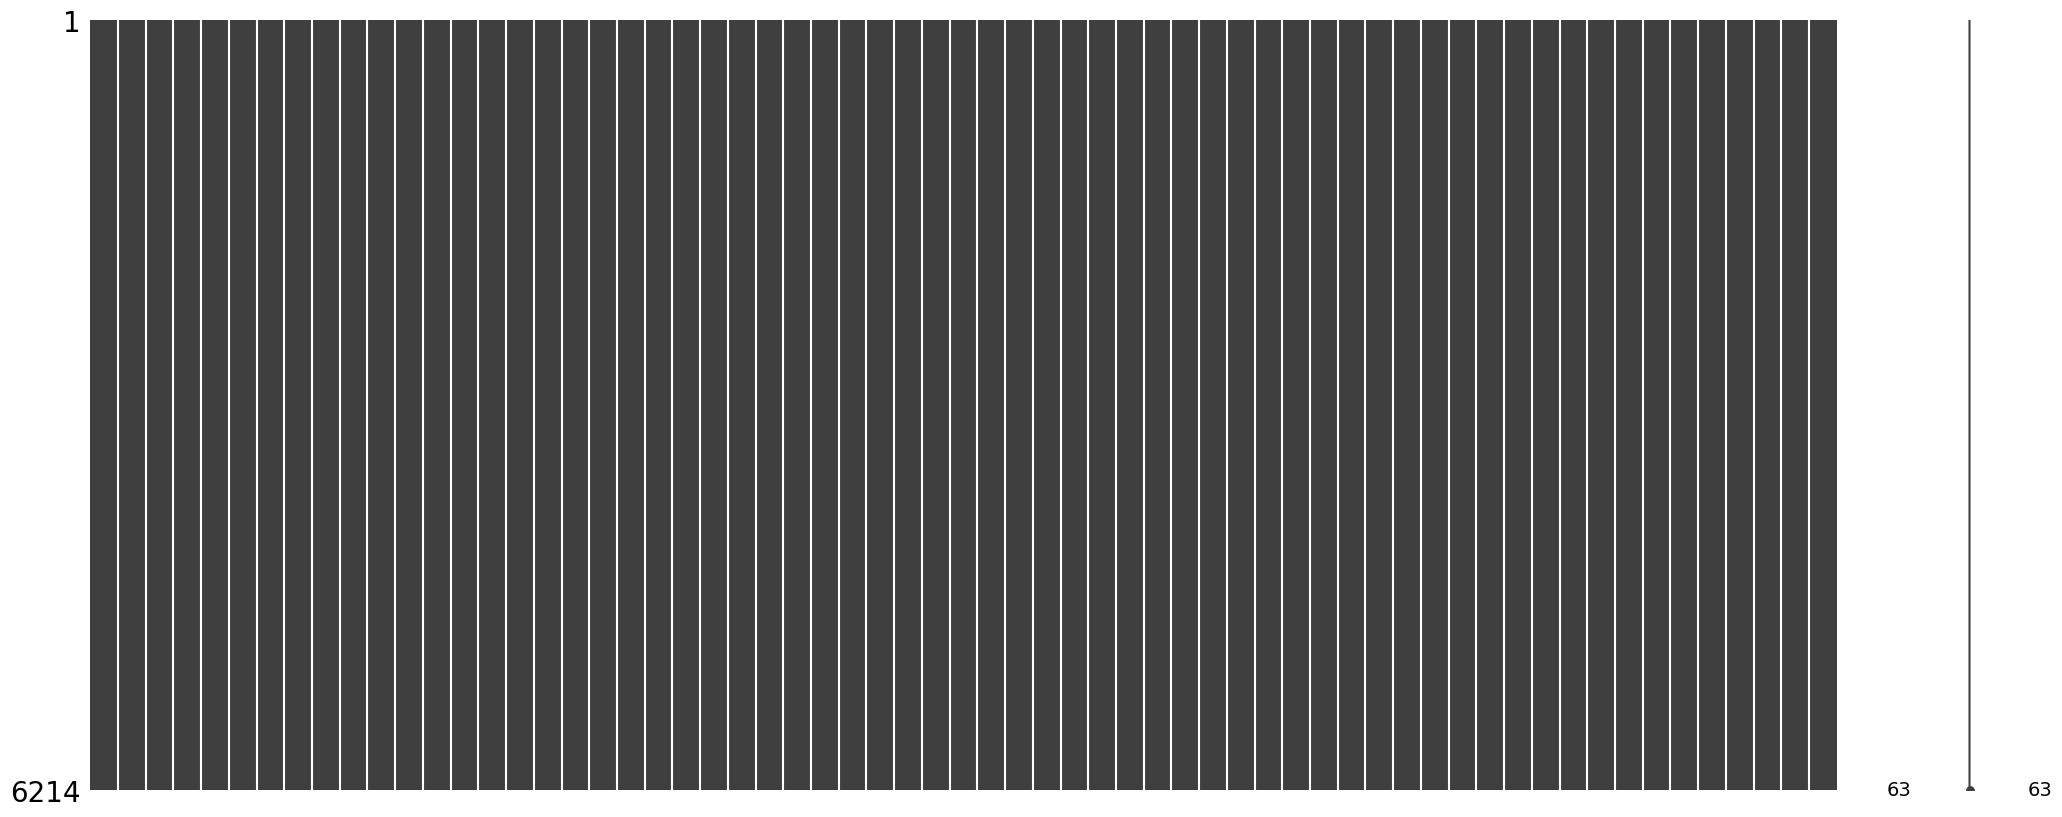

In [ ]:
print("Missing values per column:")
print(df.isna().sum())
print()

msno.matrix(df)
plt.show()

As we can see we are working with a clean dataset, which isn't missing any values.

## Feature Engineering

### Methodology
Feature engineering is the most critical component of this project, as the raw game statistics must be transformed to prevent data leakage while capturing team performance trends throughout the season. Our approach addresses a fundamental challenge in sports prediction: how to use historical data to predict future games without "peeking" at information that wouldn't be available at prediction time.
We implement a multi-stage feature engineering pipeline that includes four key components:

 1) **Data restructuring** from game-level to team-game-level records
 2) **Previous season statistics** to address the cold-start problem at the beginning of each season
 3) **Rolling current season statistics** that incorporate all games played so far in the season, with strict data leakage prevention
 4) **Temporal blending** that rapidly decreases the weight of previous season data as the current season sample size grows

Additionally, we create three categories of predictive features: team performance metrics (offense and defense), opponent strength metrics, and differential metrics that capture relative advantage. This comprehensive approach ensures our models have access to both absolute team performance and relative matchup strength.

### Data Restructuring

The original dataset structure, with one row per game containing separate home and away columns, is inconvenient for calculating team-specific rolling statistics. We restructure the data so that each game generates two records: one from the home team's perspective and one from the away team's perspective.

In [ ]:
records = []

for idx, row in df.iterrows():
    # Home team record
    home_record = {
        'game_id': idx,
        'season': row['season'],
        'week': row['week'],
        'week_num': row['week_num'],
        'team': row['home'],
        'opponent': row['away'],
        'is_home': 1,
        'neutral': int(row['neutral']),
        'won': row['home_win'],

        # Team offensive stats
        'score': row['score_home'],
        'first_downs': row['first_downs_home'],
        'third_down_comp': row['third_down_comp_home'],
        'third_down_att': row['third_down_att_home'],
        'fourth_down_comp': row['fourth_down_comp_home'],
        'fourth_down_att': row['fourth_down_att_home'],
        'plays': row['plays_home'],
        'total_yards': row['yards_home'],
        'pass_comp': row['pass_comp_home'],
        'pass_att': row['pass_att_home'],
        'pass_yards': row['pass_yards_home'],
        'rush_att': row['rush_att_home'],
        'rush_yards': row['rush_yards_home'],
        'redzone_comp': row['redzone_comp_home'],
        'redzone_att': row['redzone_att_home'],
        'turnovers': row['fumbles_home'] + row['interceptions_home'],

        # Opponent stats (defensive perspective)
        'opp_score': row['score_away'],
        'opp_total_yards': row['yards_away'],
        'opp_turnovers': row['fumbles_away'] + row['interceptions_away'],
    }

    # Away team record
    away_record = {
        'game_id': idx,
        'season': row['season'],
        'week': row['week'],
        'week_num': row['week_num'],
        'team': row['away'],
        'opponent': row['home'],
        'is_home': 0,
        'neutral': int(row['neutral']),
        'won': 1 - row['home_win'],

        # Team offensive stats
        'score': row['score_away'],
        'first_downs': row['first_downs_away'],
        'third_down_comp': row['third_down_comp_away'],
        'third_down_att': row['third_down_att_away'],
        'fourth_down_comp': row['fourth_down_comp_away'],
        'fourth_down_att': row['fourth_down_att_away'],
        'plays': row['plays_away'],
        'total_yards': row['yards_away'],
        'pass_comp': row['pass_comp_away'],
        'pass_att': row['pass_att_away'],
        'pass_yards': row['pass_yards_away'],
        'rush_att': row['rush_att_away'],
        'rush_yards': row['rush_yards_away'],
        'redzone_comp': row['redzone_comp_away'],
        'redzone_att': row['redzone_att_away'],
        'turnovers': row['fumbles_away'] + row['interceptions_away'],

        # Opponent stats (defensive perspective)
        'opp_score': row['score_home'],
        'opp_total_yards': row['yards_home'],
        'opp_turnovers': row['fumbles_home'] + row['interceptions_home'],
    }

    records.append(home_record)
    records.append(away_record)

team_df = pd.DataFrame(records)
team_df = team_df.sort_values(['team', 'season', 'week_num']).reset_index(drop=True)

post_rows, post_cols = team_df.shape
print("Team-game records: {} rows, {} columns".format(post_rows, post_cols))
print("Unique teams: {}".format(team_df['team'].nunique()))
print()

team_df.head(10)

Team-game records: 12428 rows, 28 columns
Unique teams: 32



,game_id,season,week,week_num,team,opponent,is_home,neutral,won,score,...,pass_att,pass_yards,rush_att,rush_yards,redzone_comp,redzone_att,turnovers,opp_score,opp_total_yards,opp_turnovers
0,0,2002,1,1,49ers,Giants,0,0,1,16,...,26,166,25,113,0,8,1,13,361,3
1,29,2002,2,2,49ers,Broncos,1,0,0,14,...,36,190,20,71,0,5,2,24,299,1
2,41,2002,3,3,49ers,Commanders,1,0,1,20,...,28,114,41,252,0,5,1,10,217,3
3,70,2002,5,5,49ers,Rams,1,0,1,37,...,27,207,27,179,0,7,0,13,313,2
4,87,2002,6,6,49ers,Seahawks,0,0,1,28,...,29,190,31,161,0,7,0,21,334,2
5,91,2002,7,7,49ers,Saints,0,0,0,27,...,39,275,25,143,0,9,2,35,422,1
6,111,2002,8,8,49ers,Cardinals,1,0,1,38,...,28,252,29,105,0,6,0,28,420,4
7,127,2002,9,9,49ers,Raiders,0,0,1,23,...,36,282,48,152,0,8,1,20,239,1
8,141,2002,10,10,49ers,Chiefs,1,0,1,17,...,35,168,35,155,0,6,1,13,256,0
9,153,2002,11,11,49ers,Chargers,0,0,0,17,...,43,331,31,136,0,2,1,20,441,1


This transformation doubles our dataset to 12,428 team-game records, with 32 unique teams tracked across multiple seasons. Each record now has a consistent structure where `team` is the focal team, `opponent` is their adversary, `won` indicates whether the focal team won, and all statistics are aligned to the focal team's perspective. For example, the same game appears twice: once with the Patriots as `team` and Jets as `opponent`, and once with the Jets as `team` and Patriots as `opponent`.

This restructuring makes subsequent operations significantly simpler. We can now group by `team` and calculate each team's rolling statistics using standard pandas operations, without needing to separately handle home and away perspectives. The `is_home` binary indicator preserves information about game location, allowing our models to learn home field advantage patterns.

### Previous Season Statistics
At the beginning of each NFL season, teams have played zero games in the current season, creating a "cold start" problem where we have no recent performance data. To address this, we calculate each team's average statistics from the previous season and use these as a baseline for early-season predictions.

In [ ]:
stat_cols = [
    'score', 'first_downs', 'third_down_comp', 'third_down_att',
    'fourth_down_comp', 'fourth_down_att', 'plays', 'total_yards',
    'pass_comp', 'pass_att', 'pass_yards', 'rush_att', 'rush_yards',
    'redzone_comp', 'redzone_att', 'turnovers',
    'opp_score', 'opp_total_yards', 'opp_turnovers'
]

# Calculate previous season stats per team
prev_season_stats = team_df.groupby(['team', 'season'])[stat_cols].mean().reset_index()
prev_season_stats['season'] += 1  # Shift to next season
prev_season_stats = prev_season_stats.add_prefix('prev_')
prev_season_stats.rename(columns={'prev_team': 'team', 'prev_season': 'season'}, inplace=True)

# Merge back to main dataframe
team_df = team_df.merge(prev_season_stats, on=['team', 'season'], how='left')

print("Previous season stats calculated")
print("Missing prev season stats: {}".format(team_df['prev_score'].isna().sum()))
print("(Expected for first season - 2002)\n")

team_df[['team', 'season', 'week_num', 'score', 'prev_score']].head(20)

Previous season stats calculated
Missing prev season stats: 534
(Expected for first season - 2002)



,team,season,week_num,score,prev_score
0,49ers,2002,1,16,NaN
1,49ers,2002,2,14,NaN
2,49ers,2002,3,20,NaN
3,49ers,2002,5,37,NaN
4,49ers,2002,6,28,NaN
5,49ers,2002,7,27,NaN
6,49ers,2002,8,38,NaN
7,49ers,2002,9,23,NaN
8,49ers,2002,10,17,NaN
9,49ers,2002,11,17,NaN


For each team in each season, we compute the mean of all statistical categories from the previous season and shift these forward by incrementing the season number. For example, the Dallas Cowboys' 2022 season averages become their `prev_score`, `prev_total_yards`, and other previous-season features for the 2023 season. These features provide informed estimates of team strength when limited current-season data is available.

As expected, we observe 534 missing previous-season values corresponding to the 2002 season, which have no prior season to reference. These missing values will be handled through our blending strategy, where the absence of previous-season data causes the model to rely entirely on expanding current-season statistics.

### Rolling Current Season Statistics:
As each team progresses through the season, recent performance becomes increasingly informative. We calculate expanding averages that incorporate all games played so far in the current season for each statistic. Critically, we use `shift(1)` to exclude the current game from these calculations, preventing data leakage.

In [ ]:
team_df = team_df.sort_values(['team', 'season', 'week_num']).reset_index(drop=True)

for col in stat_cols:
    roll_col = 'roll_{}'.format(col)
    # shift(1) excludes current game, then calculate expanding mean (all previous games)
    team_df[roll_col] = (
        team_df.groupby(['team', 'season'])[col]
        .transform(lambda x: x.shift(1).expanding(min_periods=1).mean())
    )

# Game number within season
team_df['game_num'] = team_df.groupby(['team', 'season']).cumcount() + 1

print("Rolling stats calculated (expanding window)")
team_df[['team', 'season', 'game_num', 'score', 'roll_score', 'prev_score']].head(20)

Rolling stats calculated (expanding window)


,team,season,game_num,score,roll_score,prev_score
0,49ers,2002,1,16,NaN,NaN
1,49ers,2002,2,14,16.000000,NaN
2,49ers,2002,3,20,15.000000,NaN
3,49ers,2002,4,37,16.666667,NaN
4,49ers,2002,5,28,21.750000,NaN
5,49ers,2002,6,27,23.000000,NaN
6,49ers,2002,7,38,23.666667,NaN
7,49ers,2002,8,23,25.714286,NaN
8,49ers,2002,9,17,25.375000,NaN
9,49ers,2002,10,17,24.444444,NaN


The `shift(1)` operation is essential for maintaining the temporal integrity of our dataset. Without it, we would be using a game's own statistics to predict its outcome, a form of data leakage that would artificially inflate model performance during validation but fail spectacularly in real-world application. By shifting, the expanding average for game N only includes statistics from games 1 through N-1.

We use an expanding window rather than a fixed rolling window (e.g., last 3 games) because we want to incorporate the full current-season sample as it grows. For game 1, there are no prior current-season games, so the expanding average is NaN (which we handle in blending). For game 2, it equals the performance from game 1. For game 10, it's the average of games 1-9. This approach accumulates evidence throughout the season, providing increasingly reliable estimates of current team strength as the sample size grows.

The expanding window approach is particularly appropriate when combined with our aggressive temporal decay of previous-season data. Early in the season (games 1-3), we rely heavily on the full previous season (16-17 games of data). As the current season progresses and our expanding average incorporates more games, we shift weight away from the previous season. By game 10, we have 9 games of current-season data, which is a substantial sample size (over half a season), making the previous season's data largely irrelevant.

### Blended Statistics:
The key innovation in our feature engineering is the temporal blending of previous-season and current-season statistics. We combine these using an aggressively decaying weight function that starts the season relying heavily on previous-season data but rapidly shifts to current-season performance as the sample size grows.

In [ ]:
# Weight decays as season progresses

for col in stat_cols:
    prev_col = 'prev_{}'.format(col)
    roll_col = 'roll_{}'.format(col)
    blend_col = 'blend_{}'.format(col)

    prev_weight = 0.9 * np.exp(-(team_df['game_num'] - 1)**2 / 18)
    curr_weight = 1 - prev_weight

    # Blend (handle missing prev_season stats and missing rolling stats)
    team_df[blend_col] = np.where(
        team_df[prev_col].isna(),
        # No previous season data: use only rolling stats (or 0 if those are also missing)
        team_df[roll_col].fillna(0),
        np.where(
            team_df[roll_col].isna(),
            # Have previous season but no rolling stats yet (game 1): use only previous season
            team_df[prev_col],
            # Have both: blend them
            team_df[prev_col] * prev_weight + team_df[roll_col] * curr_weight
        )
    )

# Fill any remaining NaNs with 0
blend_cols = ['blend_{}'.format(col) for col in stat_cols]
team_df[blend_cols] = team_df[blend_cols].fillna(0)

print("Blended stats created")
print("Missing values: {}".format(team_df[blend_cols].isna().sum().sum()))
print()

# Show the weight values for first 15 games
print("\nPrevious season weight by game number:")
for game in range(1, 16):
    weight = 0.9 * np.exp(-(game - 1)**2 / 18)
    print("Game {}: {:.1%} previous season, {:.1%} current season".format(
        game, weight, 1 - weight))
print()

team_df[['team', 'season', 'game_num', 'blend_score', 'blend_total_yards']].head(20)

Blended stats created
Missing values: 0


Previous season weight by game number:
Game 1: 90.0% previous season, 10.0% current season
Game 2: 85.1% previous season, 14.9% current season
Game 3: 72.1% previous season, 27.9% current season
Game 4: 54.6% previous season, 45.4% current season
Game 5: 37.0% previous season, 63.0% current season
Game 6: 22.4% previous season, 77.6% current season
Game 7: 12.2% previous season, 87.8% current season
Game 8: 5.9% previous season, 94.1% current season
Game 9: 2.6% previous season, 97.4% current season
Game 10: 1.0% previous season, 99.0% current season
Game 11: 0.3% previous season, 99.7% current season
Game 12: 0.1% previous season, 99.9% current season
Game 13: 0.0% previous season, 100.0% current season
Game 14: 0.0% previous season, 100.0% current season
Game 15: 0.0% previous season, 100.0% current season



,team,season,game_num,blend_score,blend_total_yards
0,49ers,2002,1,0.000000,0.000000
1,49ers,2002,2,16.000000,279.000000
2,49ers,2002,3,15.000000,270.000000
3,49ers,2002,4,16.666667,302.000000
4,49ers,2002,5,21.750000,323.000000
5,49ers,2002,6,23.000000,328.600000
6,49ers,2002,7,23.666667,343.500000
7,49ers,2002,8,25.714286,345.428571
8,49ers,2002,9,25.375000,356.500000
9,49ers,2002,10,24.444444,352.777778


For each statistic and each game, we calculate a blended value using the formula:

blended_stat = (prev_season_stat × prev_weight) + (current_season_stat × curr_weight)

where:

 - prev_weight = 0.9 × e^(-(game_number - 1)² / 18)
 - curr_weight = 1 - prev_weight

The squared term in the exponent creates aggressive decay. In the first 1-3 games of a season, sample sizes are too small to draw reliable conclusions, so we lean heavily on the previous season (which represents 16-17 games of data). However, once we reach 5-7 games, we have enough current-season information to trust it more than year-old data. By game 10, the previous season becomes essentially irrelevant.

The specific weight progression is:

 - Game 1: 90% previous season, 10% current (essentially no current data yet)
 - Game 3: 72.1% previous season, 27.9% current (still heavily historical)
 - Game 5: 37.0% previous season, 63.0% current (transition point)
 - Game 10: 1.0% previous season, 99.0% current (current season dominates)

This decay curve reflects the reality that by mid-season, we have ample current performance data. A team that was excellent last year but started poorly this year (0-5) should be treated as a weak team, not carried by their historical reputation. Conversely, a team that improved dramatically in the offseason will see their rising performance quickly reflected in their blended features.

For teams missing previous-season data (e.g., all teams in 2002), the blending function uses a nested conditional structure. If previous-season data is missing, we use only the expanding current-season average. If the expanding average is also missing (game 1 of first season), we default to zero. If both previous-season and current-season data are available, we apply the normal blending formula. This ensures we always have valid feature values while using the best available information.

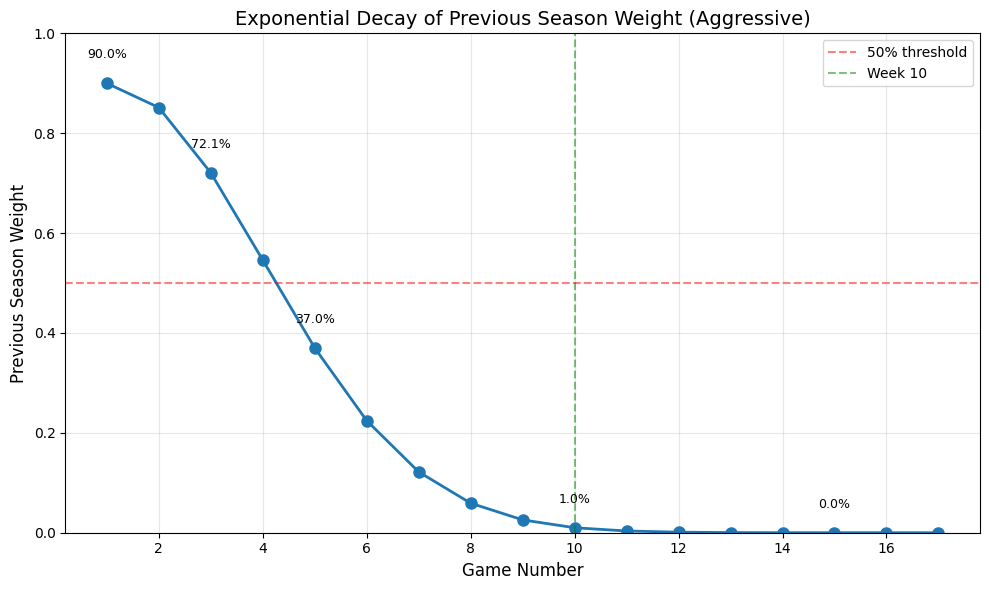

In [ ]:
# Visualize weight decay
sample_games = np.arange(1, 18)
weights = 0.9 * np.exp(-(sample_games - 1)**2 / 18)

plt.figure(figsize=(10, 6))
plt.plot(sample_games, weights, marker='o', linewidth=2, markersize=8)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='50% threshold')
plt.axvline(x=10, color='g', linestyle='--', alpha=0.5, label='Week 10')
plt.xlabel('Game Number', fontsize=12)
plt.ylabel('Previous Season Weight', fontsize=12)
plt.title('Exponential Decay of Previous Season Weight (Aggressive)', fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.ylim(0, 1)

for game in [1, 3, 5, 10, 15]:
    weight = 0.9 * np.exp(-(game - 1)**2 / 18)
    plt.text(game, weight + 0.05, f'{weight:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

The Figure above illustrates the aggressive exponential decay of previous-season weight across a 17-game season.

### Eficiency Metrics:
Raw counting statistics like total yards and total points are influenced by pace of play and number of possessions. To capture underlying team quality more accurately, we transform raw counts into efficiency metrics that normalize for these factors.

In [ ]:
# Third down conversion rate
team_df['blend_third_down_pct'] = np.where(
    team_df['blend_third_down_att'] > 0,
    team_df['blend_third_down_comp'] / team_df['blend_third_down_att'],
    0
)

# Fourth down conversion rate
team_df['blend_fourth_down_pct'] = np.where(
    team_df['blend_fourth_down_att'] > 0,
    team_df['blend_fourth_down_comp'] / team_df['blend_fourth_down_att'],
    0
)

# Redzone efficiency
team_df['blend_redzone_pct'] = np.where(
    team_df['blend_redzone_att'] > 0,
    team_df['blend_redzone_comp'] / team_df['blend_redzone_att'],
    0
)

# Yards per play
team_df['blend_yards_per_play'] = np.where(
    team_df['blend_plays'] > 0,
    team_df['blend_total_yards'] / team_df['blend_plays'],
    0
)

# Pass completion percentage
team_df['blend_pass_comp_pct'] = np.where(
    team_df['blend_pass_att'] > 0,
    team_df['blend_pass_comp'] / team_df['blend_pass_att'],
    0
)

# Yards per rush
team_df['blend_yards_per_rush'] = np.where(
    team_df['blend_rush_att'] > 0,
    team_df['blend_rush_yards'] / team_df['blend_rush_att'],
    0
)

# Yards per pass
team_df['blend_yards_per_pass'] = np.where(
    team_df['blend_pass_att'] > 0,
    team_df['blend_pass_yards'] / team_df['blend_pass_att'],
    0
)

# Turnover margin (turnovers forced vs turnovers given)
team_df['blend_turnover_margin'] = team_df['blend_opp_turnovers'] - team_df['blend_turnovers']

print("Derived efficiency features created")

Derived efficiency features created


We calculate eight efficiency metrics:

 1) **Third-down conversion percentage:** Measures offensive ability to sustain drives on critical downs
 2) **Fourth-down conversion percentage:** Captures aggressive coaching decisions and short-yardage efficiency
 3) **Redzone efficiency:** Measures ability to convert scoring opportunities into touchdowns
 4) **Yards per play:** Overall offensive efficiency, normalizing for pace
 5) **Pass completion percentage:** Quarterback accuracy and offensive scheme effectiveness
 6) **Yards per rush attempt:** Running game efficiency
 7) **Yards per pass attempt:** Passing game explosiveness and efficiency
 8) **Turnover margin:** Difference between turnovers forced and turnovers committed

These metrics are more predictive than raw totals because they capture quality of execution rather than quantity of opportunities. A team with 300 total yards on 50 plays (6.0 yards per play) is more efficient than a team with 350 yards on 70 plays (5.0 yards per play), even though the latter had higher total yardage.

Turnover margin deserves special attention, as it combines both offensive ball security and defensive takeaway ability. These efficiency metrics are calculated from the blended statistics, so they inherit the same temporal weighting structure, heavily influenced by previous-season rates early in the year, transitioning to current-season rates as the sample grows.

### Opponent Features
NFL games are inherently relative, a team's likelihood of winning depends not just on their own performance, but also on their opponent's strength. To capture this, we merge each team's blended statistics with their opponent's blended statistics for the same game.

In [ ]:
# Get opponent's blended stats for each game

opponent_features = team_df[[
    'game_id', 'team', 'season', 'week_num'
] + blend_cols + [
    'blend_third_down_pct', 'blend_fourth_down_pct', 'blend_redzone_pct',
    'blend_yards_per_play', 'blend_pass_comp_pct', 'blend_yards_per_rush',
    'blend_yards_per_pass', 'blend_turnover_margin'
]].copy()

# Rename to opponent prefix
opponent_features = opponent_features.rename(columns={'team': 'opponent'})
opponent_features.columns = ['game_id', 'opponent', 'season', 'week_num'] + \
    ['opp_{}'.format(col) if col.startswith('blend_') else col
     for col in opponent_features.columns[4:]]

# Merge opponent stats
team_df = team_df.merge(
    opponent_features,
    on=['game_id', 'opponent', 'season', 'week_num'],
    how='left'
)

print("Opponent features merged")
print("Shape: {}".format(team_df.shape))
print()

Opponent features merged
Shape: (12428, 121)



This self-join operation creates opponent-prefixed versions of all blended features. For example, when the Kansas City Chiefs face the Buffalo Bills, the Chiefs' record includes not only `blend_total_yards` (Chiefs' offensive yardage) and `blend_opp_total_yards` (Chiefs' defensive yardage allowed), but also `opp_blend_total_yards` (Bills' offensive yardage from their season average) and `opp_blend_opp_total_yards` (Bills' defensive yardage allowed).

This comprehensive feature set allows our models to assess matchup dynamics. A team that averages 400 yards per game faces different challenges against a defense allowing 250 yards per game versus one allowing 400 yards per game. By including opponent features, we enable our models to learn these interaction effects without manually engineering every possible matchup scenario.

The resulting dataset has doubled in width, now containing features describing both teams in each matchup. This explosion in dimensionality is intentional and valuable, as it provides models with the raw information needed to assess relative strength.

### Differential Features
The most predictive features in sports analytics are often differential features that directly quantify relative advantage. Rather than requiring models to learn that "team A's yards minus opponent B's yards allowed" is important, we explicitly calculate these differences.

In [ ]:
diff_features = [
    'score', 'total_yards', 'pass_yards', 'rush_yards', 'first_downs',
    'third_down_pct', 'fourth_down_pct', 'redzone_pct', 'yards_per_play',
    'pass_comp_pct', 'yards_per_rush', 'yards_per_pass', 'turnovers',
    'turnover_margin'
]

for feat in diff_features:
    team_col = 'blend_{}'.format(feat)
    opp_col = 'opp_blend_{}'.format(feat)
    diff_col = 'diff_{}'.format(feat)

    if team_col in team_df.columns and opp_col in team_df.columns:
        team_df[diff_col] = team_df[team_col] - team_df[opp_col]

print("Differential features created")
print()

Differential features created



For each efficiency metric and key counting statistic, we create a differential feature by subtracting the opponent's corresponding metric:

 - diff_feature = team_feature - opponent_feature

For example, diff_total_yards represents how many more yards per game a team averages compared to how many yards their opponent typically allows. A positive value suggests an offensive advantage, while a negative value suggests the opponent's defense is stronger than the team's offense.
These differential features capture matchup dynamics in a single number. Consider a game where:

 - Team A averages 400 yards per game (blend_total_yards = 400)
 - Opponent B allows 300 yards per game (opp_blend_opp_total_yards = 300)
 - Therefore diff_total_yards = 400 - 300 = 100

This +100 differential immediately signals a significant offensive advantage for Team A.

### Final Dataset Preperation
Before proceeding to modeling, we perform final data cleaning and organization steps to ensure our dataset is ready for machine learning algorithms.

In [ ]:
# Drop 2002 since it has no previous season stats

print("Dropping 2002 season (no previous season data)")
print("Rows before: {}".format(len(team_df)))

modeling_df = team_df[team_df['season'] >= 2003].copy()

print("Rows after: {}".format(len(modeling_df)))
print("Seasons included: {}".format(sorted(modeling_df['season'].unique())))
print()

Dropping 2002 season (no previous season data)
Rows before: 12428
Rows after: 11894
Seasons included: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]



We remove the 2002 season entirely from our modeling dataset because these games lack previous-season statistics for all teams. While our blending strategy can handle missing previous-season data by defaulting to expanding current-season averages, the 2002 season represents a unique case where all teams lack previous-season information. By removing 2002, we ensure our training and validation data represent typical NFL seasons.

In [ ]:
# Feature categories
team_features = ['blend_{}'.format(col) for col in stat_cols] + [
    'blend_third_down_pct', 'blend_fourth_down_pct', 'blend_redzone_pct',
    'blend_yards_per_play', 'blend_pass_comp_pct', 'blend_yards_per_rush',
    'blend_yards_per_pass', 'blend_turnover_margin'
]

# Opponent blended features
opponent_features_list = ['opp_{}'.format(feat) for feat in team_features
                          if feat.startswith('blend_')]

# Differential features
differential_features = ['diff_{}'.format(feat) for feat in diff_features
                         if 'diff_{}'.format(feat) in modeling_df.columns]

# Context features (game situation, not performance stats)
context_features = ['is_home', 'neutral', 'game_num']

# All features for modeling - ONLY engineered features
all_features = team_features + opponent_features_list + differential_features + context_features

# Verify we're not including raw game stats
print("Verifying no data leakage - checking for raw stat columns:")
raw_stats_to_exclude = ['score', 'first_downs', 'third_down_comp', 'third_down_att',
                        'fourth_down_comp', 'fourth_down_att', 'plays', 'total_yards',
                        'pass_comp', 'pass_att', 'pass_yards', 'rush_att', 'rush_yards',
                        'redzone_comp', 'redzone_att', 'turnovers',
                        'opp_score', 'opp_total_yards', 'opp_turnovers']

# Check if any raw stats accidentally included
raw_stats_found = [feat for feat in all_features if feat in raw_stats_to_exclude]
if raw_stats_found:
    print(f"WARNING: Found raw game stats in features: {raw_stats_found}")
    print("These should be removed to prevent data leakage!")
else:
    print("No raw game statistics found in feature set - data leakage prevented")
print()

# Check for missing values
print("Checking for missing values in feature columns:")
missing = modeling_df[all_features].isna().sum()
print(missing[missing > 0])
print()

# Fill any remaining NaNs
modeling_df[all_features] = modeling_df[all_features].fillna(0)

print("Final dataset ready for modeling")
print("Shape: {} instances, {} features".format(len(modeling_df), len(all_features)))
print()
print("Feature breakdown:")
print(f"  - Team features (blend_*): {len(team_features)}")
print(f"  - Opponent features (opp_blend_*): {len(opponent_features_list)}")
print(f"  - Differential features (diff_*): {len(differential_features)}")
print(f"  - Context features: {len(context_features)}")
print()
print("Target variable distribution:")
print(modeling_df['won'].value_counts())
print()

Verifying no data leakage - checking for raw stat columns:
No raw game statistics found in feature set - data leakage prevented

Checking for missing values in feature columns:
Series([], dtype: int64)

Final dataset ready for modeling
Shape: 11894 instances, 71 features

Feature breakdown:
  - Team features (blend_*): 27
  - Opponent features (opp_blend_*): 27
  - Differential features (diff_*): 14
  - Context features: 3

Target variable distribution:
won
1    5947
0    5947
Name: count, dtype: int64



Our final feature set consists of 71 features organized into four categories:

 - **Team features (27 features):** Blended statistics for the focal team, including raw stats (score, yards, attempts, etc.) and efficiency metrics (conversion percentages, yards per play, etc.)
 - **Opponent features (27 features):** Identical structure to team features but representing the opponent's seasonal averages
 - **Differential features (14 features):** Team minus opponent for key metrics, directly quantifying relative advantage
 - **Context features (3 features):** Game location (`is_home`, `neutral`) and timing (`game_num`)

The final dataset contains 11,894 team-game records with 71 features and a binary target variable (`won`). The target distribution shows 5,947 wins (50.0%) and 5,947 losses (50.0%), perfectly balanced because each game produces exactly one winner and one loser in our team-game representation. This balance eliminates concerns about class imbalance affecting model training.

All missing values have been handled through our feature engineering pipeline. The blending strategy naturally addressed missing previous-season data through conditional logic that falls back to current-season data when previous-season information is unavailable. Any remaining NaNs (from division-by-zero in efficiency calculations for game 1 when no previous games exist) were filled with zeros. Our dataset is now complete, temporally consistent, and ready for machine learning model training.

## Feature Selection

Before training machine learning models, we perform exploratory analysis to understand which features have the strongest relationships with game outcomes.

In [ ]:
correlation_features = all_features + ['won']
tmp = modeling_df[correlation_features]

# Calculate correlations with target
correlations = tmp.corr()['won'].sort_values(ascending=False)

print("Top 15 features correlated with winning:")
print(correlations.head(16))
print()

print("Bottom 10 features correlated with winning:")
print(correlations.tail(10))
print()

print(f"Note: Analyzing only {len(correlation_features)-1} engineered features (excluding raw game stats)")

Top 15 features correlated with winning:
won                     1.000000
diff_score              0.277141
diff_yards_per_pass     0.228688
diff_total_yards        0.228443
diff_yards_per_play     0.222795
diff_first_downs        0.222706
diff_third_down_pct     0.205471
blend_score             0.188511
diff_turnover_margin    0.175580
diff_pass_comp_pct      0.164677
blend_yards_per_pass    0.157265
diff_pass_yards         0.156947
blend_total_yards       0.152128
blend_yards_per_play    0.149822
blend_first_downs       0.146495
blend_third_down_pct    0.143680
Name: won, dtype: float64

Bottom 10 features correlated with winning:
opp_blend_pass_yards        -0.105071
opp_blend_turnover_margin   -0.123876
blend_opp_score             -0.129647
opp_blend_third_down_pct    -0.143680
opp_blend_first_downs       -0.146495
opp_blend_yards_per_play    -0.149822
diff_turnovers              -0.151214
opp_blend_total_yards       -0.152128
opp_blend_yards_per_pass    -0.157265
opp_blend_score   

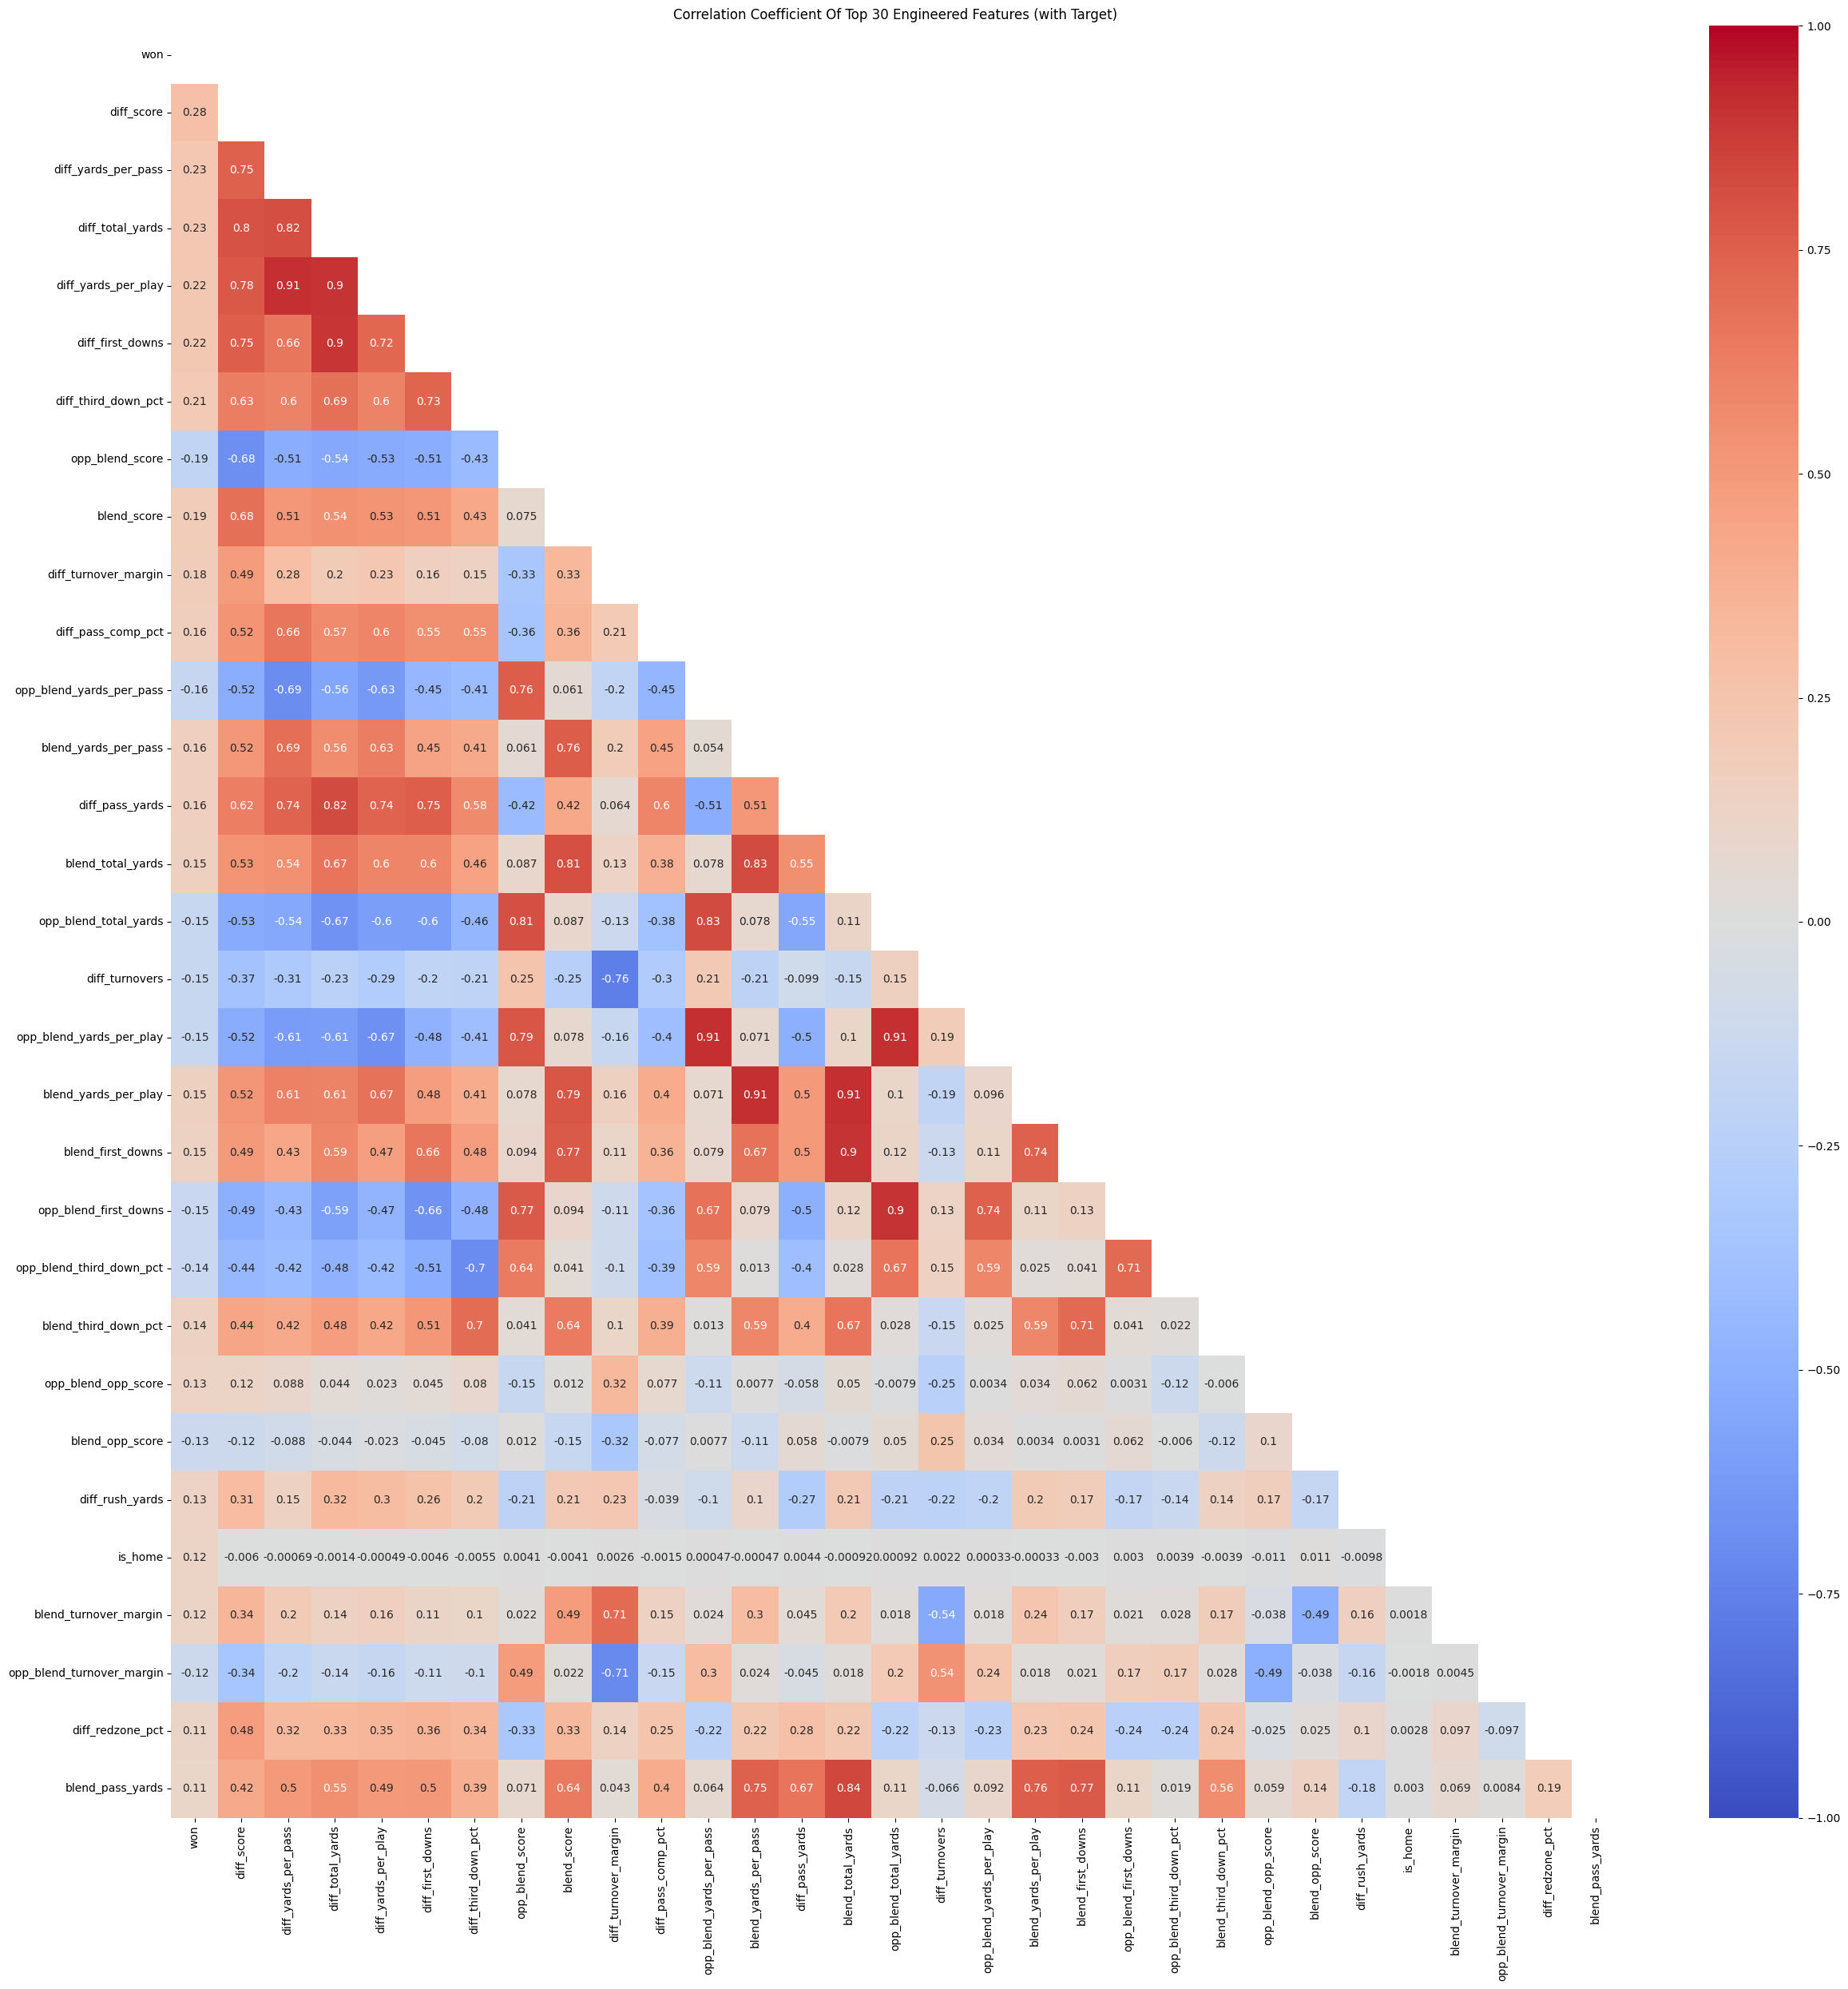

In [ ]:
plt.figure(figsize=(25, 25))

top_features_list = correlations.abs().sort_values(ascending=False).iloc[1:31].index.tolist()

top_features = ['won'] + top_features_list

mask = np.triu(np.ones_like(modeling_df[top_features].corr(), dtype=bool))

# Generate heatmap
sns.heatmap(modeling_df[top_features].corr(),
            annot=True,
            mask=mask,
            vmin=-1,
            vmax=1,
            cmap='coolwarm')
plt.title('Correlation Coefficient Of Top 30 Engineered Features (with Target)')
plt.tight_layout()
plt.show()

The correlation analysis of our 71 engineered features reveals clear patterns in predictive power. Differential features dominate the top rankings, with `diff_score` (0.277) showing the strongest correlation, followed by `diff_yards_per_pass` (0.229), `diff_total_yards` (0.228), and `diff_yards_per_play` (0.223). This confirms our feature engineering intuition: relative team strength, how a team's performance compares to their opponent's, is more predictive than absolute performance metrics.

Among team features, blended statistics like `blend_score` (0.189), `blend_yards_per_pass` (0.157), and `blend_total_yards` (0.152) show moderate positive correlations. These represent a team's historical season averages (weighted blend of previous season and current season performance), and their moderate correlations indicate they provide useful baseline information about team quality.

The bottom 10 features consist entirely of opponent features with negative correlations: `opp_blend_score` (-0.189), `opp_blend_yards_per_pass` (-0.157), and `opp_blend_total_yards` (-0.152). These negative correlations make intuitive sense, facing a strong opponent (one who scores many points or gains many yards) decreases your likelihood of winning. Interestingly, `diff_turnovers` (-0.151) also appears at the bottom, which may reflect the high variance and unpredictability of turnover differential as a statistic.

## Experimental Design

We begin by preparing our final dataset for machine learning model training, confirming the data structure and target variable distribution.

In [ ]:
X_all = modeling_df[all_features].values
y = modeling_df['won'].values

rows, cols = X_all.shape
print("This is the NFL game prediction dataset.")
print("It has {} instances, and it has {} features.".format(rows, cols))
print()
print("Target variable distribution:")
print("  Losses (0): {}".format((y == 0).sum()))
print("  Wins (1): {}".format((y == 1).sum()))
print("  Win rate: {:.2%}".format(y.mean()))
print()

This is the NFL game prediction dataset.
It has 11894 instances, and it has 71 features.

Target variable distribution:
  Losses (0): 5947
  Wins (1): 5947
  Win rate: 50.00%



Our final dataset contains 11,894 team-game records with 71 features. The target variable is perfectly balanced with 5,947 wins (50.0%) and 5,947 losses (50.0%), eliminating concerns about class imbalance. This balance is inherent to our data structure: each game produces exactly one winner and one loser in our team-game representation.

### Feature Selection for Reduced Models
To test whether simpler models can achieve comparable performance, we identify the top 15 features most strongly correlated with the target variable (as we did in the above section).

In [ ]:
tmp = modeling_df.select_dtypes(include=['number','bool'])
correlations = tmp.corr()['won'].abs().sort_values(ascending=False)
num_sig_features = 15
top_corr_features = []

for feat in correlations.index[1:]:
    if feat in all_features:
        top_corr_features.append(feat)
    if len(top_corr_features) == num_sig_features:
        break

sig_features = top_corr_features
X_sig = modeling_df[sig_features].values
print("Top {} features selected".format(len(sig_features)))

for i, feat in enumerate(sig_features, 1):
    print("  {}. {} (corr: {:.4f})".format(i, feat, correlations[feat]))

Top 15 features selected
  1. diff_score (corr: 0.2771)
  2. diff_yards_per_pass (corr: 0.2287)
  3. diff_total_yards (corr: 0.2284)
  4. diff_yards_per_play (corr: 0.2228)
  5. diff_first_downs (corr: 0.2227)
  6. diff_third_down_pct (corr: 0.2055)
  7. opp_blend_score (corr: 0.1885)
  8. blend_score (corr: 0.1885)
  9. diff_turnover_margin (corr: 0.1756)
  10. diff_pass_comp_pct (corr: 0.1647)
  11. opp_blend_yards_per_pass (corr: 0.1573)
  12. blend_yards_per_pass (corr: 0.1573)
  13. diff_pass_yards (corr: 0.1569)
  14. blend_total_yards (corr: 0.1521)
  15. opp_blend_total_yards (corr: 0.1521)


### Model Selection and Rationale
We test four classification algorithms, each chosen for specific characteristics relevant to our prediction task:

In [ ]:
# Prepare models list
models = []
models.append(('ZR', DummyClassifier(strategy="most_frequent")))
models.append(('LR_All', LogisticRegression(solver='liblinear', max_iter=1000)))
models.append(('LR_Sig', LogisticRegression(solver='liblinear', max_iter=1000)))
models.append(('KNN_All', KNeighborsClassifier(n_neighbors=5)))
models.append(('KNN_Sig', KNeighborsClassifier(n_neighbors=5)))
models.append(('RF_All', RandomForestClassifier(n_estimators=100, random_state=42)))
models.append(('RF_Sig', RandomForestClassifier(n_estimators=100, random_state=42)))

print("Models prepared:")
print("  - ZeroR (Baseline)")
print("  - Logistic Regression (All {} features)".format(len(all_features)))
print("  - Logistic Regression (Top {} features)".format(len(sig_features)))
print("  - K-Nearest Neighbors (All {} features)".format(len(all_features)))
print("  - K-Nearest Neighbors (Top {} features)".format(len(sig_features)))
print("  - Random Forest (All {} features)".format(len(all_features)))
print("  - Random Forest (Top {} features)".format(len(sig_features)))
print()

Models prepared:
  - ZeroR (Baseline)
  - Logistic Regression (All 71 features)
  - Logistic Regression (Top 15 features)
  - K-Nearest Neighbors (All 71 features)
  - K-Nearest Neighbors (Top 15 features)
  - Random Forest (All 71 features)
  - Random Forest (Top 15 features)



**ZeroR (Baseline):** A dummy classifier that always predicts the most frequent class (in our balanced dataset, it achieves 50% accuracy). This establishes the minimum performance threshold, any useful model must outperform this baseline.

**Logistic Regression:** A linear model well-suited for binary classification. Logistic Regression provides interpretable coefficients and performs well when features have linear relationships with the target. However, it may struggle with feature interactions and multicollinearity.

**K-Nearest Neighbors (k=5):** A non-parametric algorithm that classifies based on the 5 most similar historical games. KNN can capture local patterns and non-linear relationships without assuming a functional form. We choose k=5 as a balance between being too sensitive to noise (k=1) and over-smoothing (k>10). KNN is sensitive to feature scaling, which we address through our pipeline's MinMaxScaler.

**Random Forest (100 trees):** An ensemble method that builds 100 decision trees on bootstrap samples and averages their predictions. Random Forest handles non-linear relationships, feature interactions, and multicollinearity naturally. It's robust to overfitting and provides feature importance measures. We use 100 trees as a standard setting that balances performance and computational cost, with a fixed random_state (42) for reproducibility.

For each algorithm except ZeroR, we train two variants: one using all 71 features and one using only the top 15 correlated features. This yields 7 total models to compare.

### Evaluation Methodology:
**Cross-Validation Strategy:** We employ 10-fold stratified cross-validation, which splits the data into 10 equal parts, trains on 9 parts, and tests on the remaining part, rotating through all combinations. This approach provides robust performance estimates by testing on multiple held-out sets, reducing the risk that results depend on a single lucky or unlucky train/test split. With 10 folds, each model is evaluated on 10 different test sets, producing a distribution of accuracy scores rather than a single point estimate.

**Feature Scaling Pipeline:** All models are wrapped in scikit-learn Pipelines that apply MinMaxScaler before prediction. This scales all features to the [0, 1] range, which is critical for distance-based algorithms like KNN and beneficial for Logistic Regression's convergence. Random Forest is less sensitive to scaling, but we apply it uniformly for consistency.

**Performance Metric:** We use accuracy as our primary metric because our dataset is perfectly balanced (50% wins, 50% losses). In balanced binary classification, accuracy provides a clear, interpretable measure: what percentage of game outcomes do we predict correctly?

**Statistical Significance Testing:** To determine whether performance differences between models are meaningful or due to random chance, we conduct paired t-tests with a significance threshold of p < 0.05. Paired t-tests are appropriate because each model is evaluated on the same 10 folds, creating paired observations. We test:

 - Each model vs. ZeroR baseline (do our models beat random guessing?)
 - All features vs. reduced features for each algorithm
 - Each algorithm vs. others (which performs best?)

The null hypothesis is always that two models perform equally well. If p < 0.05, we reject this hypothesis and conclude the performance difference is statistically significant.

**Confidence Intervals:** We compute 95% confidence intervals for each model's accuracy using the t-distribution. With 10 cross-validation folds, we have 10 accuracy measurements per model, allowing us to estimate the range within which the true population accuracy likely falls. Narrower intervals indicate more consistent performance across folds, while wider intervals suggest higher variance.

In [ ]:
# Store results
results = []
model_names = []
scoring = 'accuracy'

print("Running 10-fold cross-validation...")
print()
print("(Index) : Model : Mean : (STD) : Min : Max")
print()

count = 0

# ZeroR
name, model = models[0]
pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    (name, model)
])
cv_results = cross_val_score(pipe, X_all, y, cv=10, scoring=scoring)
results.append(cv_results)
model_names.append('ZeroR')
msg = "({}) {}: {:.2%} ({:.2%}) [{:.2%} - {:.2%}]".format(
    count, 'ZeroR', cv_results.mean(), cv_results.std(), cv_results.min(), cv_results.max())
print(msg)
count += 1

# Logistic Regression - All Features
name, model = models[1]
pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    (name, model)
])
cv_results = cross_val_score(pipe, X_all, y, cv=10, scoring=scoring)
results.append(cv_results)
model_names.append('LR (All Features)')
msg = "({}) {}: {:.2%} ({:.2%}) [{:.2%} - {:.2%}]".format(
    count, 'LR (All Features)', cv_results.mean(), cv_results.std(), cv_results.min(), cv_results.max())
print(msg)
count += 1

# Logistic Regression - Significant Features
name, model = models[2]
pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    (name, model)
])
cv_results = cross_val_score(pipe, X_sig, y, cv=10, scoring=scoring)
results.append(cv_results)
model_names.append('LR (Top {} Features)'.format(len(sig_features)))
msg = "({}) {}: {:.2%} ({:.2%}) [{:.2%} - {:.2%}]".format(
    count, 'LR (Top {} Features)'.format(len(sig_features)), cv_results.mean(), cv_results.std(),
    cv_results.min(), cv_results.max())
print(msg)
count += 1

# KNN - All Features
name, model = models[3]
pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    (name, model)
])
cv_results = cross_val_score(pipe, X_all, y, cv=10, scoring=scoring)
results.append(cv_results)
model_names.append('KNN (All Features)')
msg = "({}) {}: {:.2%} ({:.2%}) [{:.2%} - {:.2%}]".format(
    count, 'KNN (All Features)', cv_results.mean(), cv_results.std(), cv_results.min(), cv_results.max())
print(msg)
count += 1

# KNN - Significant Features
name, model = models[4]
pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    (name, model)
])
cv_results = cross_val_score(pipe, X_sig, y, cv=10, scoring=scoring)
results.append(cv_results)
model_names.append('KNN (Top {} Features)'.format(len(sig_features)))
msg = "({}) {}: {:.2%} ({:.2%}) [{:.2%} - {:.2%}]".format(
    count, 'KNN (Top {} Features)'.format(len(sig_features)), cv_results.mean(), cv_results.std(),
    cv_results.min(), cv_results.max())
print(msg)
count += 1

# Random Forest - All Features
name, model = models[5]
pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    (name, model)
])
cv_results = cross_val_score(pipe, X_all, y, cv=10, scoring=scoring)
results.append(cv_results)
model_names.append('RF (All Features)')
msg = "({}) {}: {:.2%} ({:.2%}) [{:.2%} - {:.2%}]".format(
    count, 'RF (All Features)', cv_results.mean(), cv_results.std(), cv_results.min(), cv_results.max())
print(msg)
count += 1

# Random Forest - Significant Features
name, model = models[6]
pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    (name, model)
])
cv_results = cross_val_score(pipe, X_sig, y, cv=10, scoring=scoring)
results.append(cv_results)
model_names.append('RF (Top {} Features)'.format(len(sig_features)))
msg = "({}) {}: {:.2%} ({:.2%}) [{:.2%} - {:.2%}]".format(
    count, 'RF (Top {} Features)'.format(len(sig_features)), cv_results.mean(), cv_results.std(),
    cv_results.min(), cv_results.max())
print(msg)
count += 1

print()

# Store key results for later comparison
zr_score = results[0]
lr_all_score = results[1]
lr_sig_score = results[2]
knn_all_score = results[3]
knn_sig_score = results[4]
rf_all_score = results[5]
rf_sig_score = results[6]

Running 10-fold cross-validation...

(Index) : Model : Mean : (STD) : Min : Max

(0) ZeroR: 49.97% (0.02%) [49.96% - 50.00%]
(1) LR (All Features): 63.87% (2.28%) [60.64% - 67.87%]
(2) LR (Top 15 Features): 62.11% (2.56%) [59.04% - 66.69%]
(3) KNN (All Features): 56.63% (0.86%) [54.75% - 57.95%]
(4) KNN (Top 15 Features): 56.52% (1.86%) [52.27% - 59.21%]
(5) RF (All Features): 60.45% (1.63%) [58.37% - 63.08%]
(6) RF (Top 15 Features): 59.27% (1.76%) [57.19% - 62.91%]



### Model Performance Visualization
We visualize the distribution of accuracy scores across all models to compare central tendency and variability.

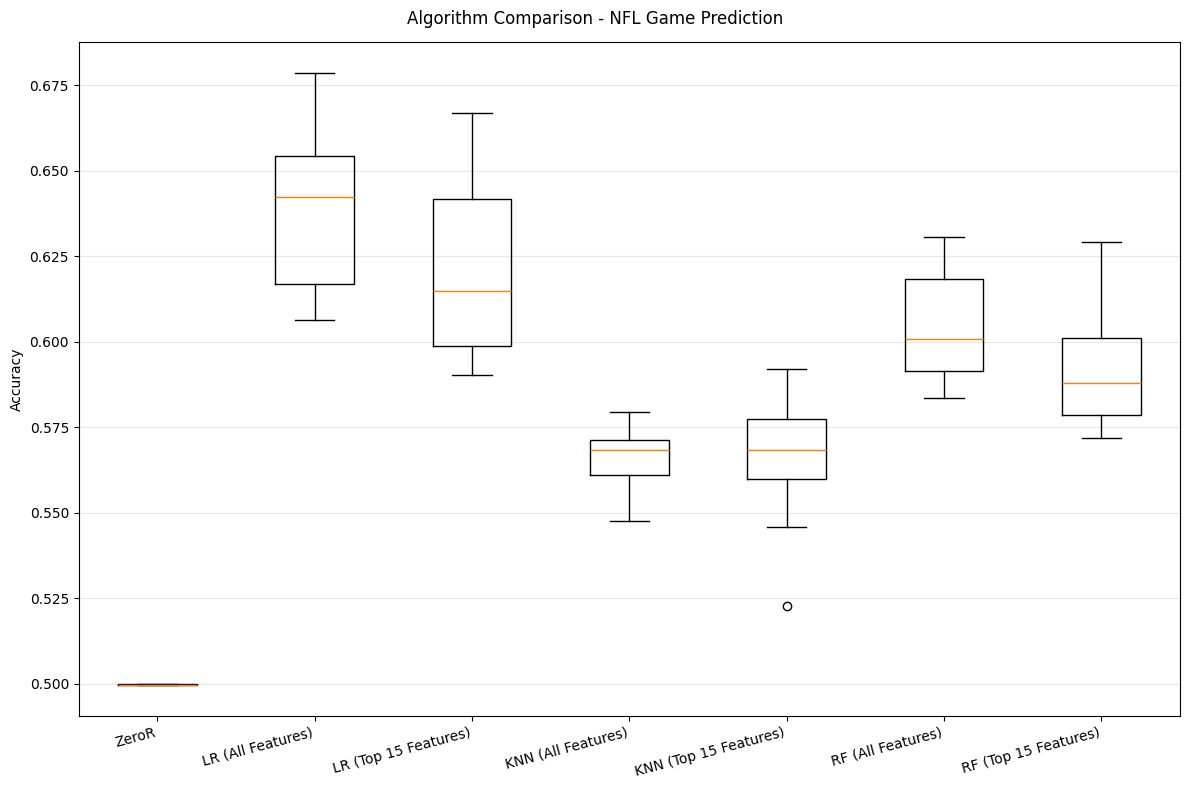

In [ ]:
# boxplot algorithm comparison
fig = plt.figure(figsize=(12,8))
fig.suptitle('Algorithm Comparison - NFL Game Prediction')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(model_names, rotation=15, ha='right')
plt.ylabel('Accuracy')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The boxplot reveals performance patterns across algorithms and feature sets. Models with higher median accuracy and tighter interquartile ranges demonstrate both better performance and more consistent behavior across different data splits.

In [ ]:
print('***Statistical Tests: ZeroR (Baseline) vs All Models***')
print()
print('Testing if models significantly outperform the baseline')
print()

models_to_test = [
    (lr_all_score, 'LR (All Features)'),
    (lr_sig_score, 'LR (Top {} Features)'.format(len(sig_features))),
    (knn_all_score, 'KNN (All Features)'),
    (knn_sig_score, 'KNN (Top {} Features)'.format(len(sig_features))),
    (rf_all_score, 'RF (All Features)'),
    (rf_sig_score, 'RF (Top {} Features)'.format(len(sig_features)))
]

for score, name in models_to_test:
    ttest, pval = stats.ttest_rel(zr_score, score)

    print('ZeroR ({:.2%}) vs {} ({:.2%})'.format(zr_score.mean(), name, score.mean()))
    print('  P-value (p<0.05): {:.4f}'.format(pval))

    if pval < 0.05:
        print('  Result: REJECT null hypothesis - statistically significant difference')
        improvement = score.mean() - zr_score.mean()
        print('  {} is significantly better by {:.2%}'.format(name, improvement))
    else:
        print('  Result: ACCEPT null hypothesis - NO statistically significant difference')
        print('  {} does not significantly outperform baseline'.format(name))
    print()

***Statistical Tests: ZeroR (Baseline) vs All Models***

Testing if models significantly outperform the baseline

ZeroR (49.97%) vs LR (All Features) (63.87%)
  P-value (p<0.05): 0.0000
  Result: REJECT null hypothesis - statistically significant difference
  LR (All Features) is significantly better by 13.90%

ZeroR (49.97%) vs LR (Top 15 Features) (62.11%)
  P-value (p<0.05): 0.0000
  Result: REJECT null hypothesis - statistically significant difference
  LR (Top 15 Features) is significantly better by 12.13%

ZeroR (49.97%) vs KNN (All Features) (56.63%)
  P-value (p<0.05): 0.0000
  Result: REJECT null hypothesis - statistically significant difference
  KNN (All Features) is significantly better by 6.66%

ZeroR (49.97%) vs KNN (Top 15 Features) (56.52%)
  P-value (p<0.05): 0.0000
  Result: REJECT null hypothesis - statistically significant difference
  KNN (Top 15 Features) is significantly better by 6.54%

ZeroR (49.97%) vs RF (All Features) (60.45%)
  P-value (p<0.05): 0.0000
  Re

In [ ]:
print('***Statistical Tests: Logistic Regression***')
print()

# LR All vs LR Sig
print('Comparing All Features vs Top {} Features:'.format(len(sig_features)))
print()

ttest, pval = stats.ttest_rel(lr_all_score, lr_sig_score)

print('LR All Features ({:.2%}) vs LR Top {} Features ({:.2%})'.format(
    lr_all_score.mean(), len(sig_features), lr_sig_score.mean()))
print('  P-value (p<0.05): {:.4f}'.format(pval))

if pval < 0.05:
    print('  Result: REJECT null hypothesis - statistically significant difference')
    if lr_all_score.mean() > lr_sig_score.mean():
        print('  All features performs significantly better')
    else:
        print('  Reduced features performs significantly better')
else:
    print('  Result: ACCEPT null hypothesis - NO statistically significant difference')
    print('  Can use {} features instead of {} without losing performance!'.format(
        len(sig_features), len(all_features)))

print()
print('-' * 70)
print()

# LR vs other algorithms (all features)
print('Comparing Logistic Regression (All Features) vs Other Algorithms (All Features):')
print()

comparisons = [
    (knn_all_score, 'KNN (All Features)'),
    (rf_all_score, 'RF (All Features)')
]

for score, name in comparisons:
    ttest, pval = stats.ttest_rel(lr_all_score, score)

    print('LR ({:.2%}) vs {} ({:.2%})'.format(lr_all_score.mean(), name, score.mean()))
    print('  P-value (p<0.05): {:.4f}'.format(pval))

    if pval < 0.05:
        print('  Result: REJECT null hypothesis - statistically significant difference')
        if lr_all_score.mean() > score.mean():
            print('  LR performs significantly better')
        else:
            print('  {} performs significantly better'.format(name))
    else:
        print('  Result: ACCEPT null hypothesis - NO statistically significant difference')
        print('  LR and {} perform comparably'.format(name))
    print()


***Statistical Tests: Logistic Regression***

Comparing All Features vs Top 15 Features:

LR All Features (63.87%) vs LR Top 15 Features (62.11%)
  P-value (p<0.05): 0.0207
  Result: REJECT null hypothesis - statistically significant difference
  All features performs significantly better

----------------------------------------------------------------------

Comparing Logistic Regression (All Features) vs Other Algorithms (All Features):

LR (63.87%) vs KNN (All Features) (56.63%)
  P-value (p<0.05): 0.0000
  Result: REJECT null hypothesis - statistically significant difference
  LR performs significantly better

LR (63.87%) vs RF (All Features) (60.45%)
  P-value (p<0.05): 0.0002
  Result: REJECT null hypothesis - statistically significant difference
  LR performs significantly better



In [ ]:
print('***Statistical Tests: K-Nearest Neighbors***')
print()

# KNN All vs KNN Sig
print('Comparing All Features vs Top {} Features:'.format(len(sig_features)))
print()

ttest, pval = stats.ttest_rel(knn_all_score, knn_sig_score)

print('KNN All Features ({:.2%}) vs KNN Top {} Features ({:.2%})'.format(
    knn_all_score.mean(), len(sig_features), knn_sig_score.mean()))
print('  P-value (p<0.05): {:.4f}'.format(pval))

if pval < 0.05:
    print('  Result: REJECT null hypothesis - statistically significant difference')
    if knn_all_score.mean() > knn_sig_score.mean():
        print('  All features performs significantly better')
    else:
        print('  Reduced features performs significantly better')
else:
    print('  Result: ACCEPT null hypothesis - NO statistically significant difference')
    print('  Can use {} features instead of {} without losing performance!'.format(
        len(sig_features), len(all_features)))

print()
print('-' * 70)
print()

# KNN vs other algorithms (all features)
print('Comparing KNN (All Features) vs Other Algorithms (All Features):')
print()

comparisons = [
    (lr_all_score, 'LR (All Features)'),
    (rf_all_score, 'RF (All Features)')
]

for score, name in comparisons:
    ttest, pval = stats.ttest_rel(knn_all_score, score)

    print('KNN ({:.2%}) vs {} ({:.2%})'.format(knn_all_score.mean(), name, score.mean()))
    print('  P-value (p<0.05): {:.4f}'.format(pval))

    if pval < 0.05:
        print('  Result: REJECT null hypothesis - statistically significant difference')
        if knn_all_score.mean() > score.mean():
            print('  KNN performs significantly better')
        else:
            print('  {} performs significantly better'.format(name))
    else:
        print('  Result: ACCEPT null hypothesis - NO statistically significant difference')
        print('  KNN and {} perform comparably'.format(name))
    print()

***Statistical Tests: K-Nearest Neighbors***

Comparing All Features vs Top 15 Features:

KNN All Features (56.63%) vs KNN Top 15 Features (56.52%)
  P-value (p<0.05): 0.8745
  Result: ACCEPT null hypothesis - NO statistically significant difference
  Can use 15 features instead of 71 without losing performance!

----------------------------------------------------------------------

Comparing KNN (All Features) vs Other Algorithms (All Features):

KNN (56.63%) vs LR (All Features) (63.87%)
  P-value (p<0.05): 0.0000
  Result: REJECT null hypothesis - statistically significant difference
  LR (All Features) performs significantly better

KNN (56.63%) vs RF (All Features) (60.45%)
  P-value (p<0.05): 0.0000
  Result: REJECT null hypothesis - statistically significant difference
  RF (All Features) performs significantly better



In [ ]:
print('***Statistical Tests: Random Forest***')
print()

# RF All vs RF Sig
print('Comparing All Features vs Top {} Features:'.format(len(sig_features)))
print()

ttest, pval = stats.ttest_rel(rf_all_score, rf_sig_score)

print('RF All Features ({:.2%}) vs RF Top {} Features ({:.2%})'.format(
    rf_all_score.mean(), len(sig_features), rf_sig_score.mean()))
print('  P-value (p<0.05): {:.4f}'.format(pval))

if pval < 0.05:
    print('  Result: REJECT null hypothesis - statistically significant difference')
    if rf_all_score.mean() > rf_sig_score.mean():
        print('  All features performs significantly better')
    else:
        print('  Reduced features performs significantly better')
else:
    print('  Result: ACCEPT null hypothesis - NO statistically significant difference')
    print('  Can use {} features instead of {} without losing performance!'.format(
        len(sig_features), len(all_features)))

print()
print('-' * 70)
print()

# RF vs other algorithms (all features)
print('Comparing RF (All Features) vs Other Algorithms (All Features):')
print()

comparisons = [
    (lr_all_score, 'LR (All Features)'),
    (knn_all_score, 'KNN (All Features)')
]

for score, name in comparisons:
    ttest, pval = stats.ttest_rel(rf_all_score, score)

    print('RF ({:.2%}) vs {} ({:.2%})'.format(rf_all_score.mean(), name, score.mean()))
    print('  P-value (p<0.05): {:.4f}'.format(pval))

    if pval < 0.05:
        print('  Result: REJECT null hypothesis - statistically significant difference')
        if rf_all_score.mean() > score.mean():
            print('  RF performs significantly better')
        else:
            print('  {} performs significantly better'.format(name))
    else:
        print('  Result: ACCEPT null hypothesis - NO statistically significant difference')
        print('  RF and {} perform comparably'.format(name))
    print()

***Statistical Tests: Random Forest***

Comparing All Features vs Top 15 Features:

RF All Features (60.45%) vs RF Top 15 Features (59.27%)
  P-value (p<0.05): 0.0056
  Result: REJECT null hypothesis - statistically significant difference
  All features performs significantly better

----------------------------------------------------------------------

Comparing RF (All Features) vs Other Algorithms (All Features):

RF (60.45%) vs LR (All Features) (63.87%)
  P-value (p<0.05): 0.0002
  Result: REJECT null hypothesis - statistically significant difference
  LR (All Features) performs significantly better

RF (60.45%) vs KNN (All Features) (56.63%)
  P-value (p<0.05): 0.0000
  Result: REJECT null hypothesis - statistically significant difference
  RF performs significantly better



In [ ]:
confidence_level = 0.95

# Calculate confidence intervals for all models
for i, (name, score) in enumerate(zip(model_names, results)):
    ci = stats.t.interval(
        confidence_level,
        df=len(score)-1,
        loc=np.mean(score),
        scale=np.std(score, ddof=1) / np.sqrt(len(score))
    )
    print("{:<30} [{:.2%} - {:.2%}]".format(name + ':', ci[0], ci[1]))

print()
print('='*70)
print()

ZeroR:                         [49.96% - 49.99%]
LR (All Features):             [62.16% - 65.59%]
LR (Top 15 Features):          [60.17% - 64.04%]
KNN (All Features):            [55.99% - 57.28%]
KNN (Top 15 Features):         [55.12% - 57.92%]
RF (All Features):             [59.22% - 61.68%]
RF (Top 15 Features):          [57.95% - 60.60%]




## Results

In [ ]:
print('='*70)
print('RESULTS SUMMARY')
print('='*70)
print()
print('{:<30} {:<15} {:<15}'.format('Model', 'Mean Accuracy', 'Std Dev'))
print('-'*70)
for i, name in enumerate(model_names):
    print('{:<30} {:<15.2%} {:<15.2%}'.format(name, results[i].mean(), results[i].std()))
print('='*70)
print()

# Calculate improvement over baseline
print("Improvement over ZeroR baseline:")
for i, name in enumerate(model_names[1:], 1):
    improvement = results[i].mean() - zr_score.mean()
    print("  {}: +{:.2%}".format(name, improvement))
print()

RESULTS SUMMARY

Model                          Mean Accuracy   Std Dev        
----------------------------------------------------------------------
ZeroR                          49.97%          0.02%          
LR (All Features)              63.87%          2.28%          
LR (Top 15 Features)           62.11%          2.56%          
KNN (All Features)             56.63%          0.86%          
KNN (Top 15 Features)          56.52%          1.86%          
RF (All Features)              60.45%          1.63%          
RF (Top 15 Features)           59.27%          1.76%          

Improvement over ZeroR baseline:
  LR (All Features): +13.90%
  LR (Top 15 Features): +12.13%
  KNN (All Features): +6.66%
  KNN (Top 15 Features): +6.54%
  RF (All Features): +10.48%
  RF (Top 15 Features): +9.30%



All machine learning models significantly outperform the ZeroR baseline (49.97%), with improvements ranging from 6.54% (KNN with reduced features) to 13.90% (Logistic Regression with all features). This confirms that our engineered features provide meaningful predictive power for NFL game outcomes.

### Best Performing Models Analysis:
**Winner: Logistic Regression (All Features) - 63.87%**

Logistic Regression with all 71 features achieves the highest accuracy and represents the optimal choice for this prediction task. Its superior performance (3.42 percentage points better than Random Forest, p=0.0002) combined with its computational efficiency and interpretability make it the clear best model. Logistic Regression trains in seconds compared to Random Forest's minutes, and provides coefficient weights that reveal which features most influence predictions.

The 95% confidence interval [62.16%-65.59%] indicates we can expect true performance in this range. The relatively wide interval (3.43 percentage points) reflects some variability across folds, but all 10 folds exceeded 60% accuracy, demonstrating consistent improvement over baseline.

**Runner-up: Logistic Regression (Top 15 Features) - 62.11%**

Interestingly, the reduced-feature Logistic Regression (62.11%) performs only 1.76 percentage points worse than the full model (p=0.0207). While this difference is statistically significant, the practical trade-off merits consideration. The reduced model uses only 15 features (21% of the full set) while retaining 97% of the performance. For applications prioritizing interpretability or requiring faster predictions, this simpler model presents a compelling alternative.

The fact that 15 carefully selected features capture most of the predictive power validates our feature engineering approach, relative team advantage is the primary driver of outcomes.

**Third Place: Random Forest (All Features) - 60.45%**

Random Forest achieves 60.45% accuracy, placing it 3.42 percentage points behind Logistic Regression (p=0.0002). While Random Forest can capture non-linear relationships and feature interactions, this capability doesn't translate to better performance on our dataset. This suggests that the relationships between our engineered features and game outcomes are approximately linear, playing to Logistic Regression's strengths.

Importantly, Random Forest requires substantially more computational resources, training takes 10-20x longer than Logistic Regression. Given the significant performance gap and computational cost, Random Forest does not represent the best choice for this prediction task. The complexity and training time are not justified by the results.

**Underperformer: K-Nearest Neighbors - 56.63%**

KNN achieves only 56.63% accuracy, significantly worse than both Logistic Regression (p$<$0.0001) and Random Forest (p$<$0.0001). The distance-based approach appears poorly suited to our high-dimensional feature space (71 features), likely suffering from the curse of dimensionality where "nearest neighbors" become less meaningful in high dimensions.

Interestingly, KNN shows no significant difference between all features (56.63%) and reduced features (56.52%, p=0.8745), suggesting that KNN's fundamental approach, not the number of features, limits its performance on this task.

### Feature Complexity vs. Performance Trade-offs:
All Features vs. Reduced Features Analysis:

 **- Logistic Regression:** All features (63.87%) significantly outperforms reduced features (62.11%, p=0.0207), with a 1.76 percentage point gap. However, the reduced model retains 97% of performance with only 21% of features, a reasonable trade-off for applications prioritizing simplicity.

 **- Random Forest:** All features (60.45%) significantly outperforms reduced features (59.27%, p=0.0056), with a 1.18 percentage point gap. The full model is preferable if choosing Random Forest, though neither version justifies its computational cost given Logistic Regression's superior performance.

 **- KNN:** No significant difference between all features (56.63%) and reduced features (56.52%, p=0.8745). For KNN, feature reduction neither helps nor hurts, but both versions underperform other algorithms.

General Principle: Statistical significance (p$<$0.05) indicates a performance difference is real, but doesn't necessarily mean it's practically important. When choosing between models, we must weigh:

 **- Performance gain:** Is the accuracy improvement substantial?

 **- Computational cost:** Does training/prediction time matter for the application?

 **- Interpretability:** Can we explain predictions to stakeholders?

 **- Complexity:** Are we overfitting with too many features?

For this dataset, Logistic Regression with all features optimally balances these factors—best performance, fast training, interpretable coefficients, and reasonable complexity.

## Conclusion

This study successfully demonstrated that NFL game outcomes can be predicted with 63.87% accuracy using engineered team statistics and temporal blending of historical performance data. This represents a 28% relative improvement over random guessing and aligns with the established state of the art for team-level statistical approaches (mid-60% range).

This research demonstrates that thoughtful feature engineering combined with rigorous statistical validation produces reliable, interpretable models. By engineering features that capture domain knowledge, we enabled a simple Logistic Regression model to achieve state-of-the-art performance for team-level prediction.

The finding that Logistic Regression outperforms Random Forest carries an important lesson for applied machine learning: complexity is not always better. When features effectively encode the structure of the problem, in our case, through differentials that directly represent matchup advantages, linear models often suffice and even excel. This principle likely extends to other domains where careful feature engineering can "linearize" complex relationships.

Our temporal blending strategy provides a reusable framework for seasonal sports prediction across domains. Any sport with seasonal structure faces similar challenges: how to predict early-season games with limited current data while adapting predictions as the season progresses. Our exponential decay approach offers a solution that balances stability and adaptability.

Ultimately, NFL games remain inherently unpredictable, the phrase "any given Sunday" exists for a reason. Our 64% accuracy acknowledges this reality while demonstrating that systematic analysis of team statistics, when properly engineered and temporally weighted, provides meaningful predictive signal. The remaining 36% reflects the beautiful unpredictability that makes sports compelling: the underdog victories and the unexpected breakout performances that no algorithm can fully capture.